# Language Translator using Encoder-Decoder LSTM

This notebook implements a language translation model using an Encoder-Decoder architecture with Long Short-Term Memory (LSTM) units. The model will translate English sentences to Marathi using the English-Marathi dataset from ManyThings.org.

## 1. Install Required Libraries

First, we install all the necessary libraries. This step ensures that our Colab environment has all the dependencies needed for TensorFlow, Pandas, NumPy, Matplotlib, and Scikit-learn.

In [4]:
!pip install tensorflow pandas numpy matplotlib scikit-learn

## 2. Import Libraries

Next, we import the essential libraries for data manipulation, building the neural network, and visualization.

In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import os
from google.colab import files

## 3. Upload Dataset

We will upload the `mar.txt` file which contains English-Marathi sentence pairs. Please click on 'Choose Files' and select `mar.txt` from your local machine.

In [6]:
uploaded = files.upload()

Saving _about.txt to _about.txt
Saving mar.txt to mar.txt


## 4. Read and Preprocess Data

We read the dataset, select the first 10,000 sentence pairs, convert English sentences to lowercase, and add explicit 'start' and 'end' tokens to Marathi sentences. This step is crucial for the sequence-to-sequence model to identify the beginning and end of target sequences.

In [7]:
lines = open("mar.txt", encoding="utf-8").read().split("\n")

input_texts = []
target_texts = []

num_samples = 10000

for line in lines[:num_samples]:
    # Split only by the first tab to handle cases where translations might contain tabs
    parts = line.split('\t')
    if len(parts) < 2:
        continue

    eng = parts[0]
    mar = parts[1]

    # Convert English sentences to lowercase
    input_texts.append(eng.lower())
    # Add explicit 'start' and 'end' tokens to Marathi sentences
    target_texts.append('start ' + mar + ' end')

print("Total Sentence Pairs:", len(input_texts))

Total Sentence Pairs: 10000


## 5. Tokenization and Sequence Preparation

We create tokenizers for both English and Marathi texts to convert words into numerical sequences. We also determine the vocabulary sizes and maximum sequence lengths, which are essential for defining our model's input shapes.

In [8]:
# Initialize Tokenizer for input (English) texts
# We use filters='' to keep all characters, including punctuation, so they can be learned.
input_tokenizer = Tokenizer(filters='')
input_tokenizer.fit_on_texts(input_texts)

# Initialize Tokenizer for target (Marathi) texts
target_tokenizer = Tokenizer(filters='')
target_tokenizer.fit_on_texts(target_texts)

# Convert text sentences to sequences of integers
input_sequences = input_tokenizer.texts_to_sequences(input_texts)
target_sequences = target_tokenizer.texts_to_sequences(target_texts)

# Calculate vocabulary sizes
input_vocab_size = len(input_tokenizer.word_index) + 1
target_vocab_size = len(target_tokenizer.word_index) + 1

# Calculate maximum sequence lengths
max_encoder_seq_length = max(len(seq) for seq in input_sequences)
max_decoder_seq_length = max(len(seq) for seq in target_sequences)

print("Input Vocabulary Size:", input_vocab_size)
print("Target Vocabulary Size:", target_vocab_size)
print("Max Encoder Sequence Length:", max_encoder_seq_length)
print("Max Decoder Sequence Length:", max_decoder_seq_length)

Input Vocabulary Size: 2753
Target Vocabulary Size: 4276
Max Encoder Sequence Length: 5
Max Decoder Sequence Length: 9


## 6. Pad Sequences

Padding sequences ensures that all input and target sequences have the same length, which is required for batch processing in neural networks. We pad the sequences with zeros.

In [9]:
# Pad the encoder input sequences
encoder_input_data = pad_sequences(
    input_sequences,
    maxlen=max_encoder_seq_length,
    padding='post'
)

# Pad the decoder input sequences
decoder_input_data = pad_sequences(
    target_sequences,
    maxlen=max_decoder_seq_length,
    padding='post'
)

# Create decoder target data (shifted by one timestep for teacher forcing)
decoder_target_data = np.zeros_like(decoder_input_data)
decoder_target_data[:, :-1] = decoder_input_data[:, 1:]

# Expand dimensions for sparse_categorical_crossentropy loss
decoder_target_data = np.expand_dims(
    decoder_target_data,
    -1
)

## 7. Build Encoder-Decoder Model

We construct the Encoder-Decoder architecture. The encoder processes the input English sentence and produces a context vector (states). The decoder uses this context vector and the 'start' token to generate the Marathi translation word by word.

In [10]:
latent_dim = 256  # Dimensionality of the latent space

# --- Encoder ---
encoder_inputs = Input(shape=(None,), name='encoder_input') # Input for encoder (English sequence)

# Embedding layer for encoder inputs
enc_emb = Embedding(
    input_vocab_size, # English vocabulary size
    latent_dim,
    name='encoder_embedding'
)(encoder_inputs)

# LSTM layer for encoder
# `return_state=True` means it returns the hidden state and cell state
encoder_lstm = LSTM(
    latent_dim,
    return_state=True,
    name='encoder_lstm'
)

# Get encoder outputs and states
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)
encoder_states = [state_h, state_c] # Store states to pass to the decoder

# --- Decoder ---
decoder_inputs = Input(shape=(None,), name='decoder_input') # Input for decoder (Marathi sequence, shifted)

# Embedding layer for decoder inputs. Reused in inference model.
dec_emb_layer = Embedding(
    target_vocab_size, # Marathi vocabulary size
    latent_dim,
    name='decoder_embedding'
)
dec_emb = dec_emb_layer(decoder_inputs)

# LSTM layer for decoder
# `return_sequences=True` returns output for each timestep
# `return_state=True` returns the hidden state and cell state for inference
decoder_lstm = LSTM(
    latent_dim,
    return_sequences=True,
    return_state=True,
    name='decoder_lstm'
)

# Pass encoder states as initial states for the decoder
decoder_outputs, _, _ = decoder_lstm(
    dec_emb,
    initial_state=encoder_states
)

# Dense layer to output probabilities for each word in the Marathi vocabulary
decoder_dense = Dense(
    target_vocab_size,
    activation='softmax',
    name='decoder_dense'
)
decoder_outputs = decoder_dense(decoder_outputs)

# --- Full Model ---
# Define the full model that takes encoder and decoder inputs and outputs decoder predictions
model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs,
    name='seq2seq_model'
)

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
model.summary()

Model: "seq2seq_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, None, 256) │    704,768 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, None, 256) │  1,094,656 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 256),     │    525,312 │ encoder_embeddin… │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, None,     │    525,312 │ decoder_embeddin… │
│                     │ 256), (None,      │            │ encoder_lstm[0][… │
│                     │ 256), (None,      │            │ encoder_lstm[0][… │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, None,      │  1,098,932 │ decoder_lstm[0][… │
│ (Dense)             │ 4276)             │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,948,980 (15.06 MB)

 Trainable params: 3,948,980 (15.06 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Train the Model

We train the model using the prepared input and target sequences. Training proceeds for 50 epochs with a batch size of 64 and a validation split of 20%.

In [11]:
epochs = 50
batch_size = 64
validation_split = 0.2

history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=validation_split
)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 119s 894ms/step - accuracy: 0.5964 - loss: 3.0992 - val_accuracy: 0.6059 - val_loss: 2.8218
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 144s 908ms/step - accuracy: 0.6638 - loss: 2.2193 - val_accuracy: 0.6090 - val_loss: 2.7201
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 140s 895ms/step - accuracy: 0.6744 - loss: 2.0544 - val_accuracy: 0.6271 - val_loss: 2.6046
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 137s 852ms/step - accuracy: 0.6964 - loss: 1.9117 - val_accuracy: 0.6406 - val_loss: 2.5442
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 142s 855ms/step - accuracy: 0.7080 - loss: 1.7885 - val_accuracy: 0.6455 - val_loss: 2.4909
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 142s 853ms/step - accuracy: 0.7191 - loss: 1.6699 - val_accuracy: 0.6565 - val_loss: 2.4488
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 106s 848ms/step - accuracy: 0.7322 - loss: 1.5488 - val_accuracy: 0.6660 - val_loss: 2.4100
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 106s 841ms/step - accuracy: 0.7446 -

## 9. Plot Training History

Visualizing the training and validation accuracy helps us understand the model's performance and detect overfitting or underfitting.

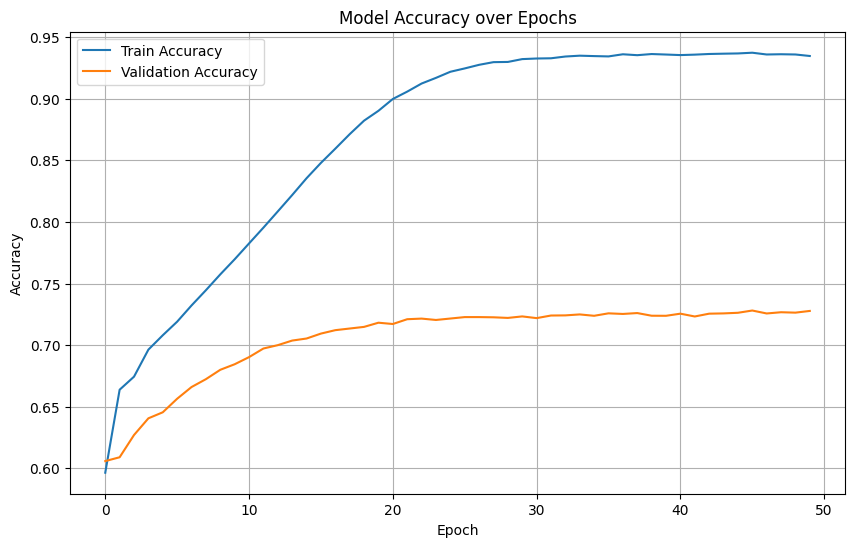

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy over Epochs")
plt.legend()
plt.grid(True)
plt.show()

## 10. Save the Model

We save the trained model to a file so it can be reused later without retraining.

In [13]:
model.save("english_marathi_translation.h5")
print("Model Saved Successfully")

Model Saved Successfully


## 11. Build Inference Models

For translation inference, we need separate encoder and decoder models. The encoder will take an English sentence and output its final states. The decoder will take these states and the target sequence (starting with 'start' token) to generate the translation word by word.

In [14]:
# Encoder Inference Model
encoder_model = Model(encoder_inputs, encoder_states, name='encoder_inference_model')

# Decoder State Inputs (for inference)
decoder_state_input_h = Input(shape=(latent_dim,), name='decoder_state_input_h')
decoder_state_input_c = Input(shape=(latent_dim,), name='decoder_state_input_c')
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

# Reuse the decoder embedding layer from the training model
dec_emb2 = dec_emb_layer(decoder_inputs)

# Reuse the decoder LSTM layer from the training model
# Get the decoder outputs and new states
decoder_outputs2, state_h2, state_c2 = decoder_lstm(
    dec_emb2,
    initial_state=decoder_states_inputs
)
decoder_states = [state_h2, state_c2] # New states for the next step

# Reuse the decoder Dense layer from the training model
decoder_outputs2 = decoder_dense(decoder_outputs2)

# Decoder Inference Model
decoder_model = Model(
    [decoder_inputs] + decoder_states_inputs,
    [decoder_outputs2] + decoder_states,
    name='decoder_inference_model'
)

## 12. Create Reverse Dictionaries

These dictionaries are used to convert the predicted integer tokens back into words for both English and Marathi, which is essential for understanding the model's output.

In [15]:
# Reverse-lookup token index to word for input (English) vocabulary
reverse_input_word_index = {idx: word for word, idx in input_tokenizer.word_index.items()}

# Reverse-lookup token index to word for target (Marathi) vocabulary
reverse_target_word_index = {idx: word for word, idx in target_tokenizer.word_index.items()}

# Store the target word index for easy lookup of 'start' and 'end' tokens
target_word_index = target_tokenizer.word_index

## 13. `translate_sentence` Function

This function takes an English sentence, encodes it, and then uses the decoder model to predict the Marathi translation word by word. It implements greedy decoding, stopping when the 'end' token is predicted or a maximum length is reached.

In [16]:
def translate_sentence(sentence):
    # 1. Convert input sentence to sequence
    # Convert the sentence to lowercase and then to a sequence of integers
    seq = input_tokenizer.texts_to_sequences([sentence.lower()])

    # Pad the sequence to the maximum encoder sequence length
    seq = pad_sequences(
        seq,
        maxlen=max_encoder_seq_length,
        padding='post'
    )

    # 2. Encode sentence to get initial states for the decoder
    states_value = encoder_model.predict(seq, verbose=0)

    # 3. Initialize target sequence with the 'start' token
    # Create a 1x1 array for the current word, starting with the 'start' token's index
    target_seq = np.zeros((1, 1))
    # Get the index for the 'start' token from the target_word_index
    target_seq[0, 0] = target_word_index['start']

    stop_condition = False
    decoded_sentence = ""
    max_translation_words = 25 # Limit to 25 words to prevent infinite loops

    while not stop_condition:
        # 4. Predict the next token and states using the decoder model
        output_tokens, h, c = decoder_model.predict(
            [target_seq] + states_value,
            verbose=0
        )

        # 5. Sample the next word (greedy decoding: take the word with highest probability)
        # The output_tokens is a probability distribution over the vocabulary
        sampled_token_index = np.argmax(output_tokens[0, -1, :])

        # Convert the sampled token index back to a word
        sampled_word = reverse_target_word_index.get(
            sampled_token_index,
            '' # Handle unknown words gracefully by returning an empty string
        )

        # 6. Check for stop conditions: 'end' token or max length
        if sampled_word == 'end':
            stop_condition = True
        elif sampled_word == '' or len(decoded_sentence.split()) >= max_translation_words:
            # Stop if an unknown word is predicted or sentence exceeds max words
            stop_condition = True
        else:
            # Append the predicted word to the decoded sentence
            decoded_sentence += sampled_word + " "

        # 7. Update the target sequence and decoder states for the next timestep
        # The current predicted word becomes the input for the next step
        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = sampled_token_index
        states_value = [h, c] # Update states to the newly generated states

    return decoded_sentence.strip()

## 14. Interactive Translation Demonstration

Here, you can enter English sentences and get their Marathi translations. Type 'exit' to quit the interactive loop.

In [17]:
print("Enter English sentences for Marathi translation. Type 'exit' to quit.")
while True:
    sentence = input("Enter English sentence: ")

    if sentence.lower() == "exit":
        break

    translation = translate_sentence(sentence)

    print("English  :", sentence)
    print("Marathi  :", translation)
    print("\n" + "-"*30 + "\n")

Enter English sentences for Marathi translation. Type 'exit' to quit.
Enter English sentence: Hello
English  : Hello
Marathi  : ते श्वास आहे.

------------------------------

Enter English sentence: exit


## 15. Demonstration Translations

Let's demonstrate the translations for a few predefined English sentences.

In [18]:
sample_sentences = [
    "Hello",
    "How are you?",
    "Good morning",
    "I love India.",
    "Thank you.",
    "What is your name?",
    "I am fine."
]

for sentence in sample_sentences:
    translation = translate_sentence(sentence)
    print(f"English  : {sentence}")
    print(f"Marathi  : {translation}")
    print("\n" + "-"*30 + "\n")

English  : Hello
Marathi  : ते श्वास आहे.

------------------------------

English  : How are you?
Marathi  : कसा आहेस?

------------------------------

English  : Good morning
Marathi  : उपास आहे.

------------------------------

English  : I love India.
Marathi  : मला खूप वास आवडतो.

------------------------------

English  : Thank you.
Marathi  : धन्यवाद.

------------------------------

English  : What is your name?
Marathi  : तुझी तुझी आहे का?

------------------------------

English  : I am fine.
Marathi  : मी बरा आहे.

------------------------------



In [19]:
!pip install tensorflow pandas numpy matplotlib scikit-learn

In [20]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import os

In [21]:
from google.colab import files

uploaded = files.upload()

Saving _about.txt to _about (1).txt
Saving mar.txt to mar (1).txt


In [22]:
lines = open("mar.txt", encoding="utf-8").read().split("\n")

input_texts = []
target_texts = []

num_samples = 10000

for line in lines[:num_samples]:
    if '\t' not in line:
        continue

    eng, mar = line.split('\t')[:2]

    target = '\t ' + mar + ' \n'

    input_texts.append(eng.lower())
    target_texts.append(target)

print("Total Sentence Pairs:", len(input_texts))

Total Sentence Pairs: 10000


In [23]:
input_tokenizer = Tokenizer(filters='')
input_tokenizer.fit_on_texts(input_texts)

target_tokenizer = Tokenizer(filters='')
target_tokenizer.fit_on_texts(target_texts)

input_sequences = input_tokenizer.texts_to_sequences(input_texts)
target_sequences = target_tokenizer.texts_to_sequences(target_texts)

input_vocab_size = len(input_tokenizer.word_index) + 1
target_vocab_size = len(target_tokenizer.word_index) + 1

max_encoder_seq_length = max(len(seq) for seq in input_sequences)
max_decoder_seq_length = max(len(seq) for seq in target_sequences)

print("Input Vocabulary:", input_vocab_size)
print("Target Vocabulary:", target_vocab_size)

Input Vocabulary: 2753
Target Vocabulary: 4276


In [24]:
encoder_input_data = pad_sequences(
    input_sequences,
    maxlen=max_encoder_seq_length,
    padding='post'
)

decoder_input_data = pad_sequences(
    target_sequences,
    maxlen=max_decoder_seq_length,
    padding='post'
)

decoder_target_data = np.zeros_like(decoder_input_data)

decoder_target_data[:, :-1] = decoder_input_data[:, 1:]

In [25]:
latent_dim = 256

encoder_inputs = Input(shape=(None,))

enc_emb = Embedding(input_vocab_size,
                    latent_dim)(encoder_inputs)

encoder_lstm = LSTM(
    latent_dim,
    return_state=True
)

encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)

encoder_states = [state_h, state_c]

In [26]:
decoder_inputs = Input(shape=(None,))

dec_emb_layer = Embedding(target_vocab_size,
                          latent_dim)

dec_emb = dec_emb_layer(decoder_inputs)

decoder_lstm = LSTM(
    latent_dim,
    return_sequences=True,
    return_state=True
)

decoder_outputs, _, _ = decoder_lstm(
    dec_emb,
    initial_state=encoder_states
)

decoder_dense = Dense(
    target_vocab_size,
    activation='softmax'
)

decoder_outputs = decoder_dense(decoder_outputs)

In [27]:
model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs
)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │    704,768 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, None, 256) │  1,094,656 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 256),     │    525,312 │ embedding[0][0]   │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, None,     │    525,312 │ embedding_1[0][0… │
│                     │ 256), (None,      │            │ lstm[0][1],       │
│                     │ 256), (None,      │            │ lstm[0][2]        │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, None,      │  1,098,932 │ lstm_1[0][0]      │
│                     │ 4276)             │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,948,980 (15.06 MB)

 Trainable params: 3,948,980 (15.06 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
decoder_target_data = np.expand_dims(
    decoder_target_data,
    -1
)

In [ ]:
history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=64,
    epochs=50,
    validation_split=0.2
)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 116s 865ms/step - accuracy: 0.6015 - loss: 3.0945 - val_accuracy: 0.6063 - val_loss: 2.8061
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 109s 872ms/step - accuracy: 0.6631 - loss: 2.2075 - val_accuracy: 0.6089 - val_loss: 2.7189
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 109s 870ms/step - accuracy: 0.6744 - loss: 2.0541 - val_accuracy: 0.6280 - val_loss: 2.5900
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 110s 879ms/step - accuracy: 0.6958 - loss: 1.9123 - val_accuracy: 0.6383 - val_loss: 2.5486
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 142s 882ms/step - accuracy: 0.7055 - loss: 1.7887 - val_accuracy: 0.6443 - val_loss: 2.4984
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 105s 839ms/step - accuracy: 0.7182 - loss: 1.6672 - val_accuracy: 0.6501 - val_loss: 2.4707
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 108s 866ms/step - accuracy: 0.7336 - loss: 1.5420 - val_accuracy: 0.6612 - val_loss: 2.3792
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 143s 873ms/step - accuracy: 0.7471 -

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [ ]:
model.save("english_marathi_translation.h5")

print("Model Saved Successfully")